In [1]:
# ==========================
# Import Required Libraries
# ==========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

# Better chart style
plt.style.use('ggplot')

# Load Cleaned Dataset
df = pd.read_csv("Cleaned_Superstore.csv")

# Display first 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Quarter,Shipping Days,Profit Margin (%)
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2017,November,4,3,16.00
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2017,November,4,3,30.00
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2017,June,2,4,47.00
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2016,October,4,7,-40.00
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2016,October,4,7,11.25


In [2]:
# Dataset Information

print("Dataset Shape:", df.shape)

print("\nColumns:\n")
print(df.columns)

print("\nDataset Information:\n")
df.info()

Dataset Shape: (9994, 26)

Columns:

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Order Year',
       'Order Month', 'Order Quarter', 'Shipping Days', 'Profit Margin (%)'],
      dtype='object')

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Row ID             9994 non-null   int64  
 1   Order ID           9994 non-null   object 
 2   Order Date         9994 non-null   object 
 3   Ship Date          9994 non-null   object 
 4   Ship Mode          9994 non-null   object 
 5   Customer ID        9994 non-null   object 
 6   Customer Name      9994 non-null   object 


In [3]:
# Summary Statistics

df.describe()

,Row ID,Sales,Quantity,Discount,Profit,Order Year,Order Quarter,Shipping Days,Profit Margin (%)
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,229.858001,3.789574,0.156203,28.656896,2016.722233,2.882329,3.958475,12.031393
std,2885.163629,623.245101,2.225110,0.206452,234.260108,1.123555,1.058086,1.747603,46.675435
min,1.000000,0.444000,1.000000,0.000000,-6599.978000,2015.000000,1.000000,0.000000,-275.000000
25%,2499.250000,17.280000,2.000000,0.000000,1.728750,2016.000000,2.000000,3.000000,7.500000
50%,4997.500000,54.490000,3.000000,0.200000,8.666500,2017.000000,3.000000,4.000000,27.000000
75%,7495.750000,209.940000,5.000000,0.200000,29.364000,2018.000000,4.000000,5.000000,36.250000
max,9994.000000,22638.480000,14.000000,0.800000,8399.976000,2018.000000,4.000000,7.000000,50.000000


In [4]:
# ======================
# Key Performance Indicators
# ======================

total_sales = df["Sales"].sum()

total_profit = df["Profit"].sum()

total_orders = df["Order ID"].nunique()

average_order_value = total_sales / total_orders

print(f"Total Sales        : ${total_sales:,.2f}")

print(f"Total Profit       : ${total_profit:,.2f}")

print(f"Total Orders       : {total_orders}")

print(f"Average Order Value: ${average_order_value:,.2f}")

Total Sales        : $2,297,200.86
Total Profit       : $286,397.02
Total Orders       : 5009
Average Order Value: $458.61


## Business Insight

The company generated strong overall sales while maintaining positive profitability. The average order value indicates the typical revenue earned per customer order and serves as a key metric for evaluating sales performance.

In [5]:
# Sales by Category

category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

category_sales

,Sales
Category,
Technology,836154.0330
Furniture,741999.7953
Office Supplies,719047.0320


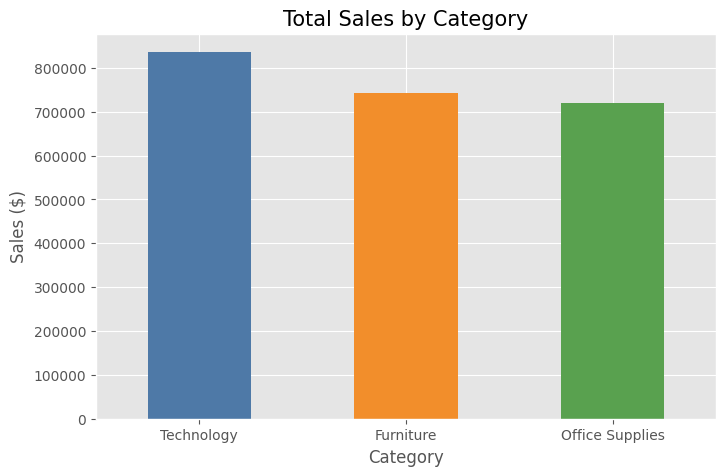

In [6]:
plt.figure(figsize=(8,5))

category_sales.plot(kind="bar", color=["#4E79A7", "#F28E2B", "#59A14F"])

plt.title("Total Sales by Category", fontsize=15)

plt.xlabel("Category")

plt.ylabel("Sales ($)")

plt.xticks(rotation=0)

plt.show()

In [7]:
category_profit = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

category_profit

,Profit
Category,
Technology,145454.9481
Office Supplies,122490.8008
Furniture,18451.2728


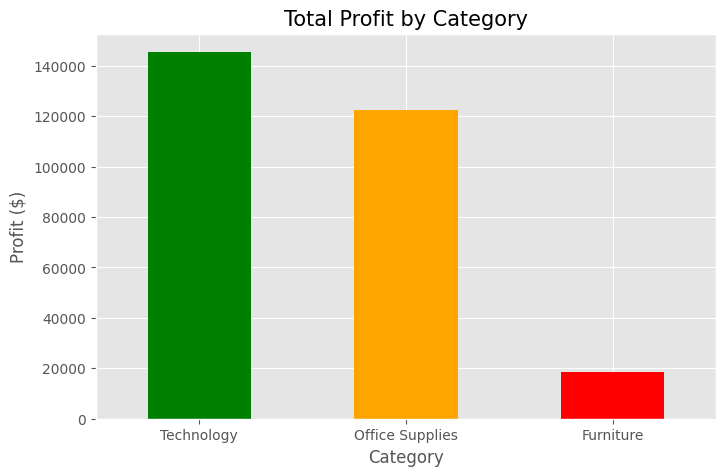

In [8]:
plt.figure(figsize=(8,5))

category_profit.plot(kind="bar", color=["green","orange","red"])

plt.title("Total Profit by Category", fontsize=15)

plt.xlabel("Category")

plt.ylabel("Profit ($)")

plt.xticks(rotation=0)

plt.show()

## Business Insight

The Technology category generated the highest sales and profit, making it the strongest-performing product category.

Furniture generated substantial sales but comparatively lower profit, suggesting that higher discounts or costs may be reducing profitability.

Office Supplies contributed steady sales and profit, indicating consistent customer demand.

# Exploratory Data Analysis (EDA)

## 1. KPI Analysis

## 2. Category Performance Analysis

## 3. Sub-Category Analysis

## 4. Regional Analysis

## 5. Customer Segment Analysis

...

In [9]:
# Sales by Sub-Category

subcategory_sales = (
    df.groupby("Sub-Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

subcategory_sales

,Sales
Sub-Category,
Phones,330007.0540
Chairs,328449.1030
Storage,223843.6080
Tables,206965.5320
Binders,203412.7330
Machines,189238.6310
Accessories,167380.3180
Copiers,149528.0300
Bookcases,114879.9963


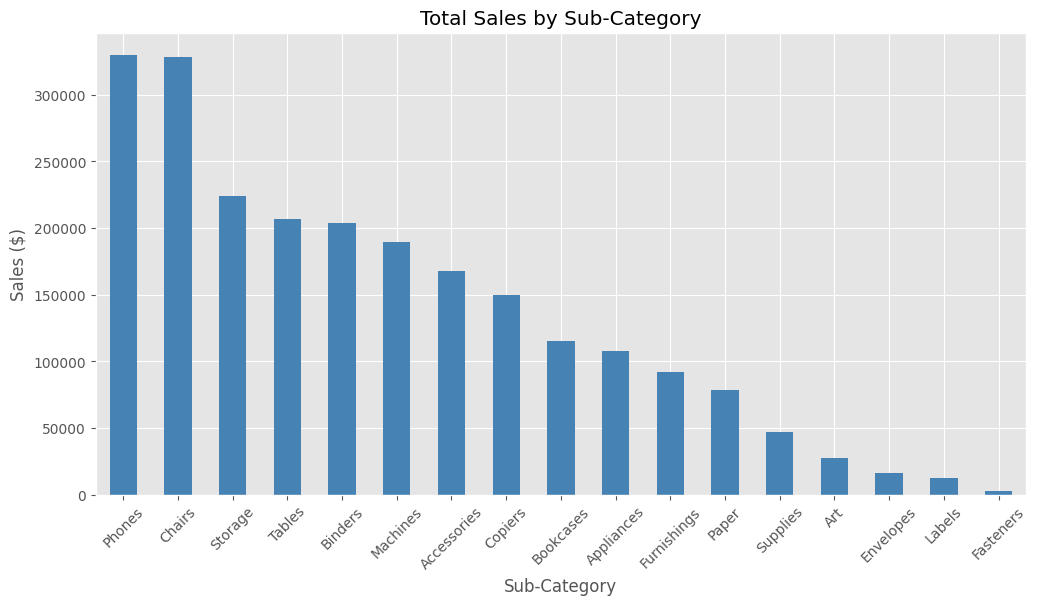

In [10]:
plt.figure(figsize=(12,6))

subcategory_sales.plot(
    kind="bar",
    color="steelblue"
)

plt.title("Total Sales by Sub-Category")

plt.xlabel("Sub-Category")

plt.ylabel("Sales ($)")

plt.xticks(rotation=45)

plt.show()

In [12]:
top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

,Sales
Product Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895
GBC DocuBind P400 Electric Binding System,17965.068


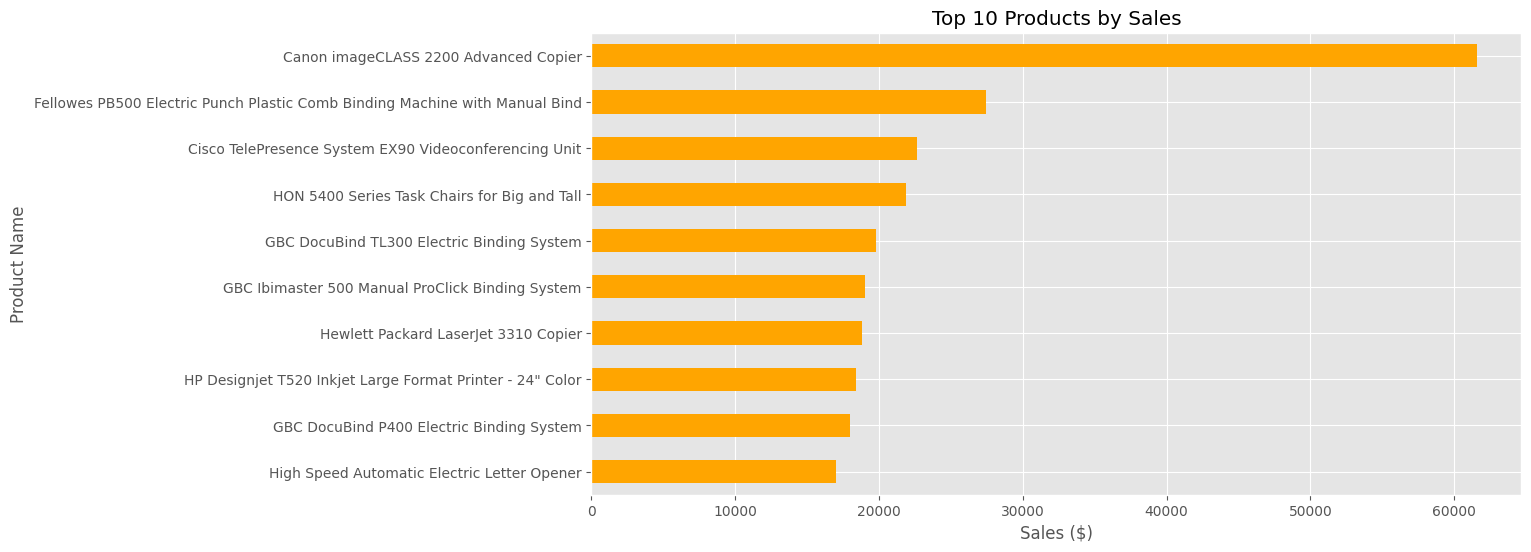

In [13]:
plt.figure(figsize=(12,6))

top_products.plot(
    kind="barh",
    color="orange"
)

plt.title("Top 10 Products by Sales")

plt.xlabel("Sales ($)")

plt.gca().invert_yaxis()

plt.show()

## Business Insight

The sub-category analysis provides a more detailed view of product performance than the category-level analysis.

Some sub-categories contribute significantly to revenue but generate relatively low profit, indicating potential issues with pricing, discounts, or operational costs.

The Top 10 Products analysis identifies the products that contribute the highest sales and can guide inventory planning and promotional strategies.

In [14]:
# Sales by Region
region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

region_sales

,Sales
Region,
West,725457.8245
East,678781.2400
Central,501239.8908
South,391721.9050


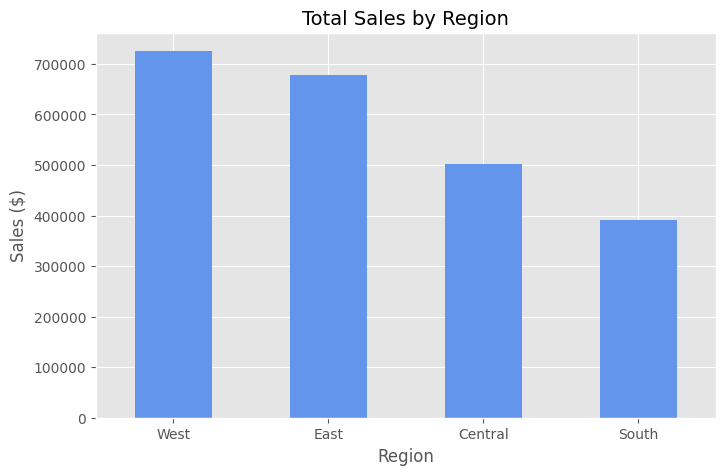

In [15]:
plt.figure(figsize=(8,5))

region_sales.plot(
    kind="bar",
    color="cornflowerblue"
)

plt.title("Total Sales by Region", fontsize=14)

plt.xlabel("Region")

plt.ylabel("Sales ($)")

plt.xticks(rotation=0)

plt.show()

In [16]:
region_profit = (
    df.groupby("Region")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

region_profit

,Profit
Region,
West,108418.4489
East,91522.7800
South,46749.4303
Central,39706.3625


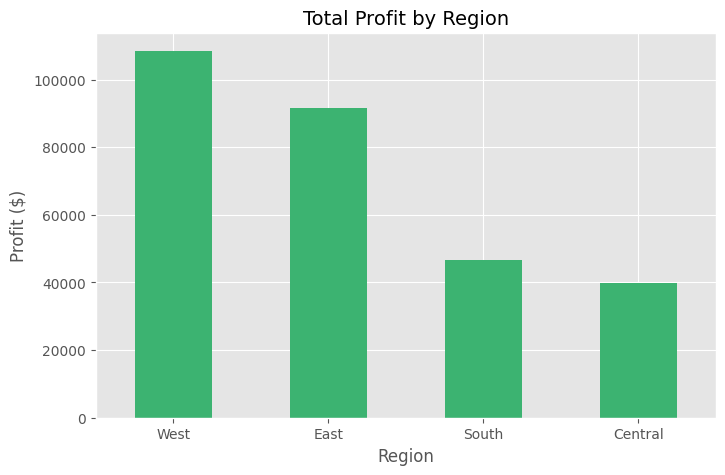

In [17]:
plt.figure(figsize=(8,5))

region_profit.plot(
    kind="bar",
    color="mediumseagreen"
)

plt.title("Total Profit by Region", fontsize=14)

plt.xlabel("Region")

plt.ylabel("Profit ($)")

plt.xticks(rotation=0)

plt.show()

In [20]:
top_states = (
    df.groupby("State")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_states

,Sales
State,
California,457687.6315
New York,310876.2710
Texas,170188.0458
Washington,138641.2700
Pennsylvania,116511.9140
Florida,89473.7080
Illinois,80166.1010
Ohio,78258.1360
Michigan,76269.6140


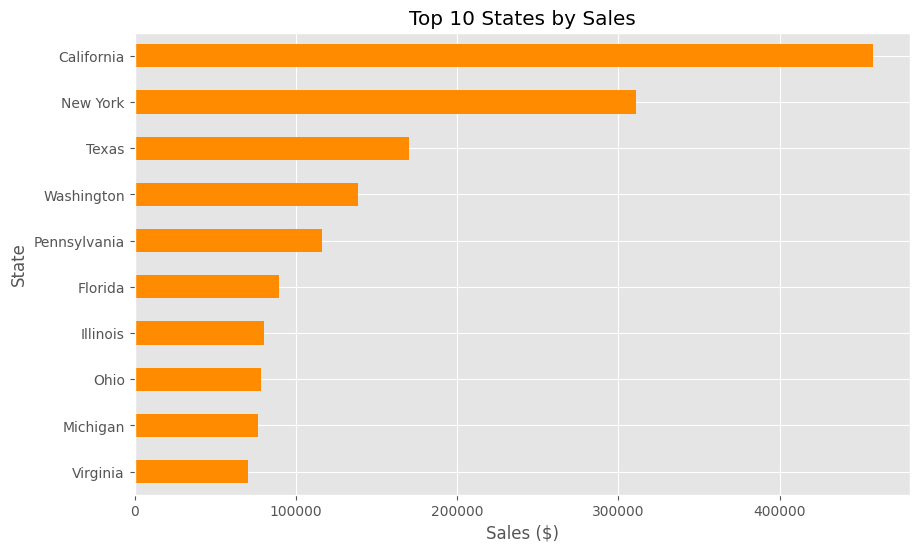

In [21]:
plt.figure(figsize=(10,6))

top_states.plot(
    kind="barh",
    color="darkorange"
)

plt.title("Top 10 States by Sales")

plt.xlabel("Sales ($)")

plt.gca().invert_yaxis()

plt.show()

In [22]:
bottom_profit = (
    df.groupby("State")["Profit"]
      .sum()
      .sort_values()
      .head(10)
)

bottom_profit

,Profit
State,
Texas,-25729.3563
Ohio,-16971.3766
Pennsylvania,-15559.9603
Illinois,-12607.8870
North Carolina,-7490.9122
Colorado,-6527.8579
Tennessee,-5341.6936
Arizona,-3427.9246
Florida,-3399.3017


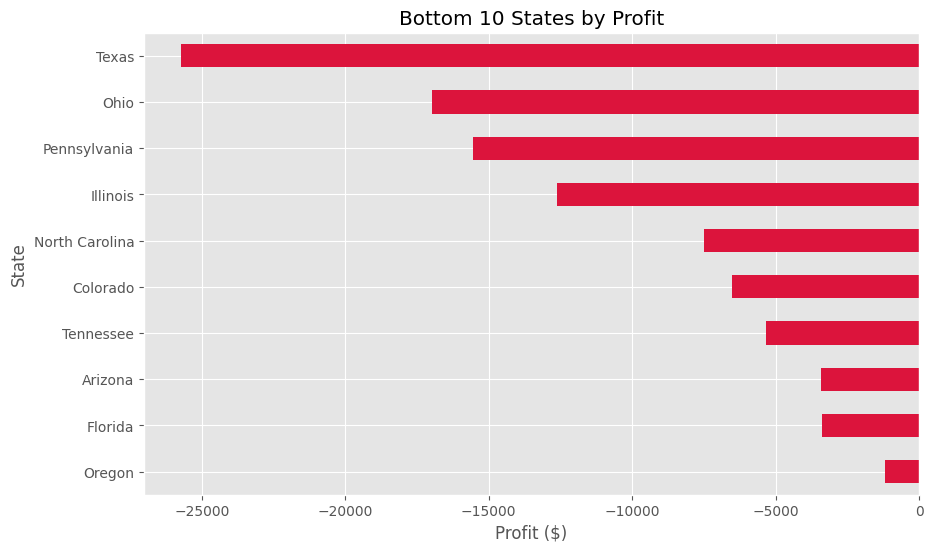

In [23]:
plt.figure(figsize=(10,6))

bottom_profit.plot(
    kind="barh",
    color="crimson"
)

plt.title("Bottom 10 States by Profit")

plt.xlabel("Profit ($)")

plt.gca().invert_yaxis()

plt.show()

## Business Insight

The regional analysis highlights geographical differences in business performance.

Some regions generate high sales and profit, making them ideal for future investment and expansion. In contrast, certain states experience low or negative profitability, suggesting the need to review pricing strategies, operational costs, or discount policies.

Understanding regional performance enables businesses to allocate resources more effectively and improve overall profitability.

In [24]:
# Sales by Customer Segment
segment_sales = (
    df.groupby("Segment")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

segment_sales

,Sales
Segment,
Consumer,1.161401e+06
Corporate,7.061464e+05
Home Office,4.296531e+05


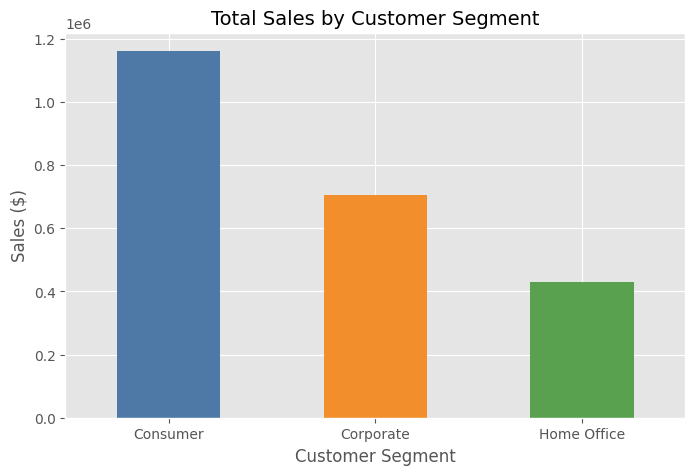

In [25]:
plt.figure(figsize=(8,5))

segment_sales.plot(
    kind="bar",
    color=["#4E79A7", "#F28E2B", "#59A14F"]
)

plt.title("Total Sales by Customer Segment", fontsize=14)
plt.xlabel("Customer Segment")
plt.ylabel("Sales ($)")
plt.xticks(rotation=0)

plt.savefig("segment_sales.png", dpi=300, bbox_inches="tight")

plt.show()

In [26]:
segment_profit = (
    df.groupby("Segment")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

segment_profit

,Profit
Segment,
Consumer,134119.2092
Corporate,91979.1340
Home Office,60298.6785


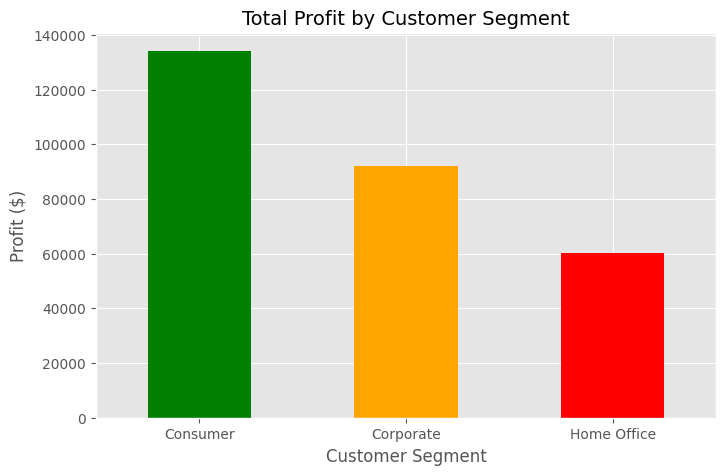

In [27]:
plt.figure(figsize=(8,5))

segment_profit.plot(
    kind="bar",
    color=["green", "orange", "red"]
)

plt.title("Total Profit by Customer Segment", fontsize=14)
plt.xlabel("Customer Segment")
plt.ylabel("Profit ($)")
plt.xticks(rotation=0)

plt.savefig("segment_profit.png", dpi=300, bbox_inches="tight")

plt.show()

In [28]:
top_customers = (
    df.groupby("Customer Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers

,Sales
Customer Name,
Sean Miller,25043.050
Tamara Chand,19052.218
Raymond Buch,15117.339
Tom Ashbrook,14595.620
Adrian Barton,14473.571
Ken Lonsdale,14175.229
Sanjit Chand,14142.334
Hunter Lopez,12873.298
Sanjit Engle,12209.438


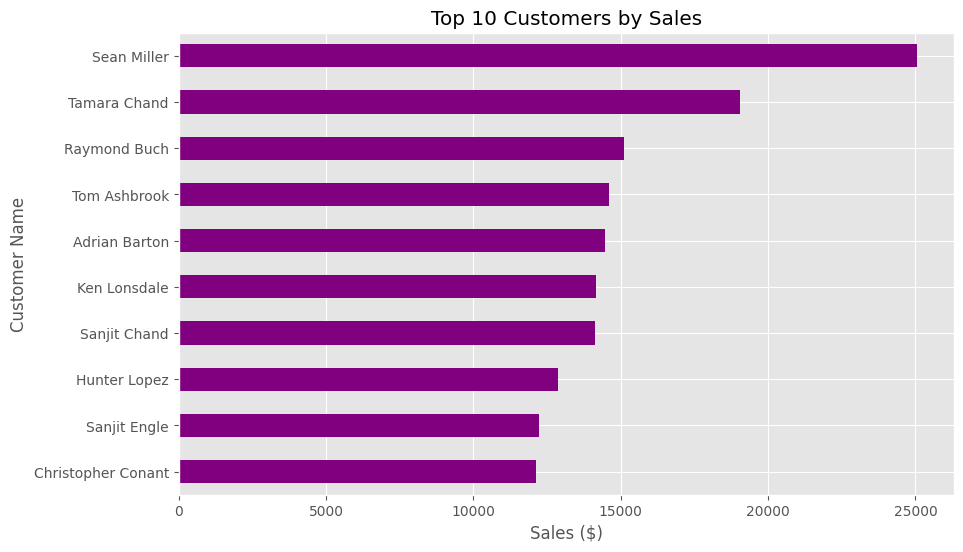

In [29]:
plt.figure(figsize=(10,6))

top_customers.plot(
    kind="barh",
    color="purple"
)

plt.title("Top 10 Customers by Sales")
plt.xlabel("Sales ($)")

plt.gca().invert_yaxis()

plt.savefig("top_customers.png", dpi=300, bbox_inches="tight")

plt.show()

## Business Insight

The customer segment analysis helps identify which customer groups contribute the highest revenue and profit.

Understanding customer segments allows businesses to develop targeted marketing strategies, improve customer retention, and allocate resources more effectively.

The Top 10 Customers analysis highlights high-value customers who can be prioritized through loyalty programs and personalized offers.

## Business Insight

The customer segment analysis helps identify which customer groups contribute the highest revenue and profit.

Understanding customer segments allows businesses to develop targeted marketing strategies, improve customer retention, and allocate resources more effectively.

The Top 10 Customers analysis highlights high-value customers who can be prioritized through loyalty programs and personalized offers.

In [30]:
# Monthly Sales Trend

monthly_sales = (
    df.groupby("Order Month")["Sales"]
      .sum()
)

# Arrange months in calendar order
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_sales = monthly_sales.reindex(month_order)

monthly_sales

,Sales
Order Month,
January,94924.8356
February,59751.2514
March,205005.4888
April,137762.1286
May,155028.8117
June,152718.6793
July,147238.0970
August,159044.0630
September,307649.9457


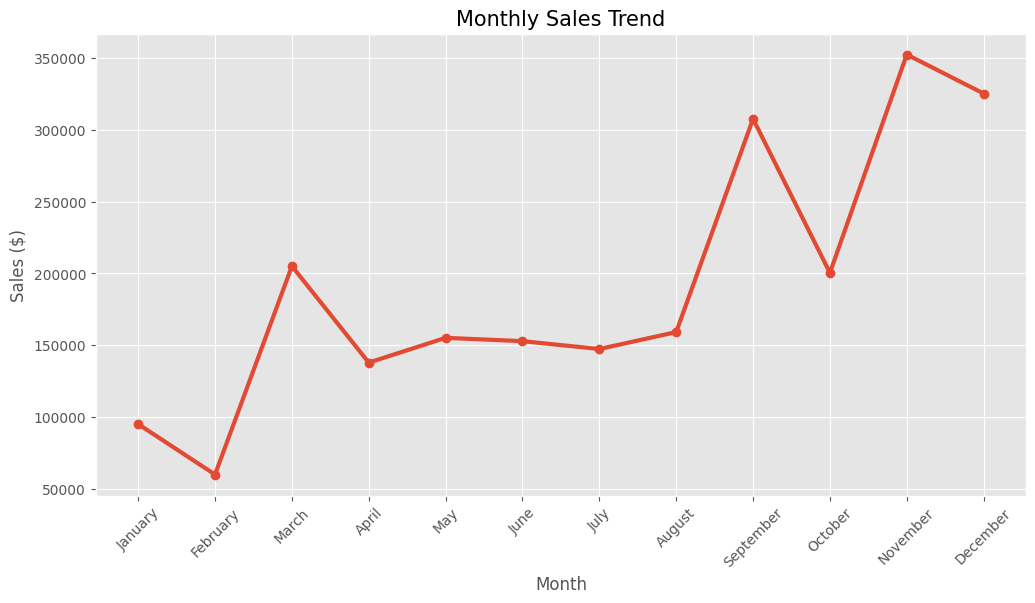

In [31]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o',
    linewidth=3
)

plt.title("Monthly Sales Trend", fontsize=15)

plt.xlabel("Month")

plt.ylabel("Sales ($)")

plt.xticks(rotation=45)

plt.grid(True)

plt.savefig("monthly_sales_trend.png", dpi=300, bbox_inches="tight")

plt.show()

In [32]:
yearly_sales = (
    df.groupby("Order Year")["Sales"]
      .sum()
)

yearly_sales

,Sales
Order Year,
2015,484247.4981
2016,470532.5090
2017,609205.5980
2018,733215.2552


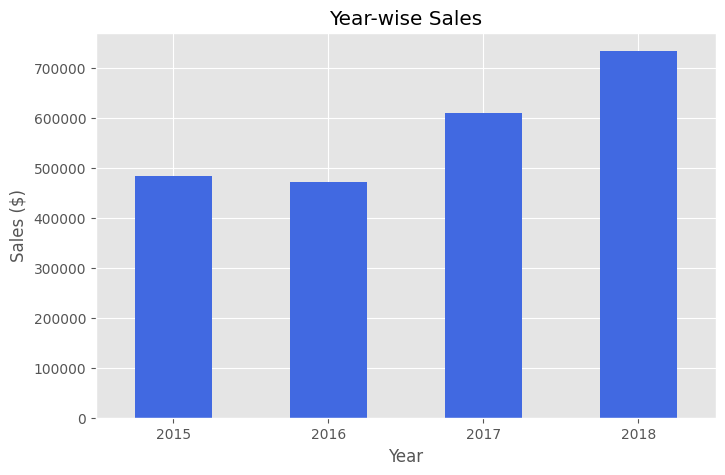

In [33]:
plt.figure(figsize=(8,5))

yearly_sales.plot(
    kind="bar",
    color="royalblue"
)

plt.title("Year-wise Sales")

plt.xlabel("Year")

plt.ylabel("Sales ($)")

plt.xticks(rotation=0)

plt.savefig("yearly_sales.png", dpi=300, bbox_inches="tight")

plt.show()

## Business Insight

The time series analysis reveals how sales fluctuate throughout the year. Identifying seasonal peaks and low-performing months helps businesses plan inventory, marketing campaigns, and staffing more effectively.

The yearly sales trend also provides an overview of business growth and long-term performance.

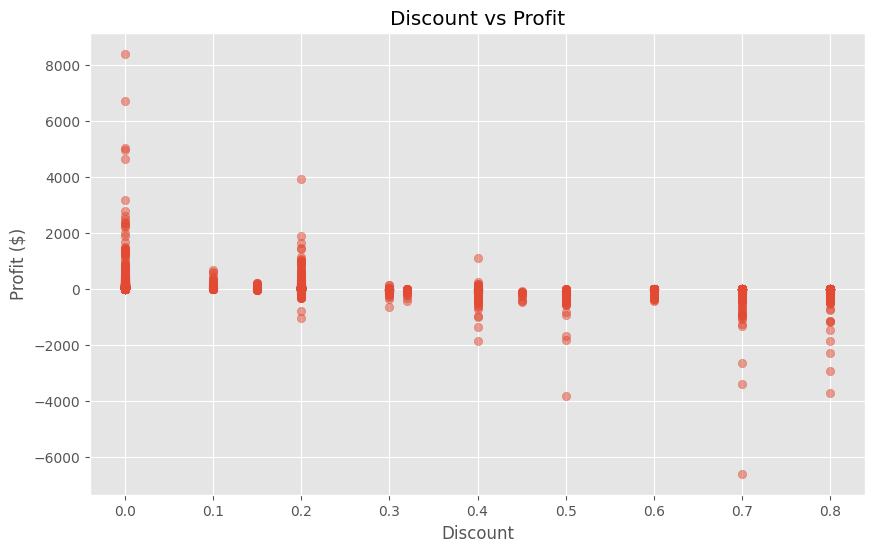

In [34]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Discount"],
    df["Profit"],
    alpha=0.5
)

plt.title("Discount vs Profit")

plt.xlabel("Discount")

plt.ylabel("Profit ($)")

plt.grid(True)

plt.savefig("discount_vs_profit.png", dpi=300, bbox_inches="tight")

plt.show()

In [35]:
correlation = df[["Discount","Profit"]].corr()

correlation

,Discount,Profit
Discount,1.000000,-0.219487
Profit,-0.219487,1.000000


## Business Insight

The scatter plot illustrates the relationship between discount and profit.

A negative relationship suggests that larger discounts often reduce profitability. Businesses should carefully evaluate discount strategies to ensure that increased sales do not come at the expense of overall profit.

In [36]:
# Average Shipping Days

average_shipping = df["Shipping Days"].mean()

print(f"Average Shipping Time: {average_shipping:.2f} Days")

Average Shipping Time: 3.96 Days


In [37]:
shipping_mode = (
    df.groupby("Ship Mode")["Order ID"]
      .count()
      .sort_values(ascending=False)
)

shipping_mode

,Order ID
Ship Mode,
Standard Class,5968
Second Class,1945
First Class,1538
Same Day,543


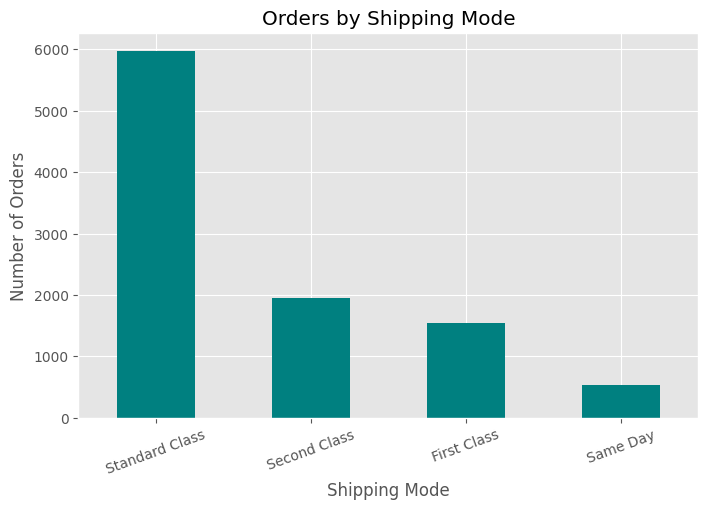

In [38]:
plt.figure(figsize=(8,5))

shipping_mode.plot(
    kind="bar",
    color="teal"
)

plt.title("Orders by Shipping Mode")

plt.xlabel("Shipping Mode")

plt.ylabel("Number of Orders")

plt.xticks(rotation=20)

plt.savefig("shipping_mode.png", dpi=300, bbox_inches="tight")

plt.show()

## Business Insight

The shipping analysis helps evaluate delivery efficiency and customer service performance.

Understanding the most frequently used shipping methods enables businesses to optimize logistics while balancing delivery speed and operational costs.

In [40]:
# Select numerical columns

numeric_columns = df.select_dtypes(include=["number"])

numeric_columns.head()

,Row ID,Sales,Quantity,Discount,Profit,Order Year,Order Quarter,Shipping Days,Profit Margin (%)
0,1,261.9600,2,0.00,41.9136,2017,4,3,16.00
1,2,731.9400,3,0.00,219.5820,2017,4,3,30.00
2,3,14.6200,2,0.00,6.8714,2017,2,4,47.00
3,4,957.5775,5,0.45,-383.0310,2016,4,7,-40.00
4,5,22.3680,2,0.20,2.5164,2016,4,7,11.25


In [41]:
correlation = numeric_columns.corr()

correlation

,Row ID,Sales,Quantity,Discount,Profit,Order Year,Order Quarter,Shipping Days,Profit Margin (%)
Row ID,1.000000,-0.001359,-0.004016,0.013480,0.012497,0.015430,-0.021651,-0.001634,-0.020355
Sales,-0.001359,1.000000,0.200795,-0.028190,0.479064,-0.009679,-0.002501,-0.007285,0.003444
Quantity,-0.004016,0.200795,1.000000,0.008623,0.066253,-0.005810,0.026546,0.018494,-0.005280
Discount,0.013480,-0.028190,0.008623,1.000000,-0.219487,-0.002662,-0.001620,0.000306,-0.864452
Profit,0.012497,0.479064,0.066253,-0.219487,1.000000,0.004670,-0.002830,-0.004672,0.223732
Order Year,0.015430,-0.009679,-0.005810,-0.002662,0.004670,1.000000,-0.020005,-0.023050,0.000039
Order Quarter,-0.021651,-0.002501,0.026546,-0.001620,-0.002830,-0.020005,1.000000,0.004826,0.006531
Shipping Days,-0.001634,-0.007285,0.018494,0.000306,-0.004672,-0.023050,0.004826,1.000000,-0.011846
Profit Margin (%),-0.020355,0.003444,-0.005280,-0.864452,0.223732,0.000039,0.006531,-0.011846,1.000000


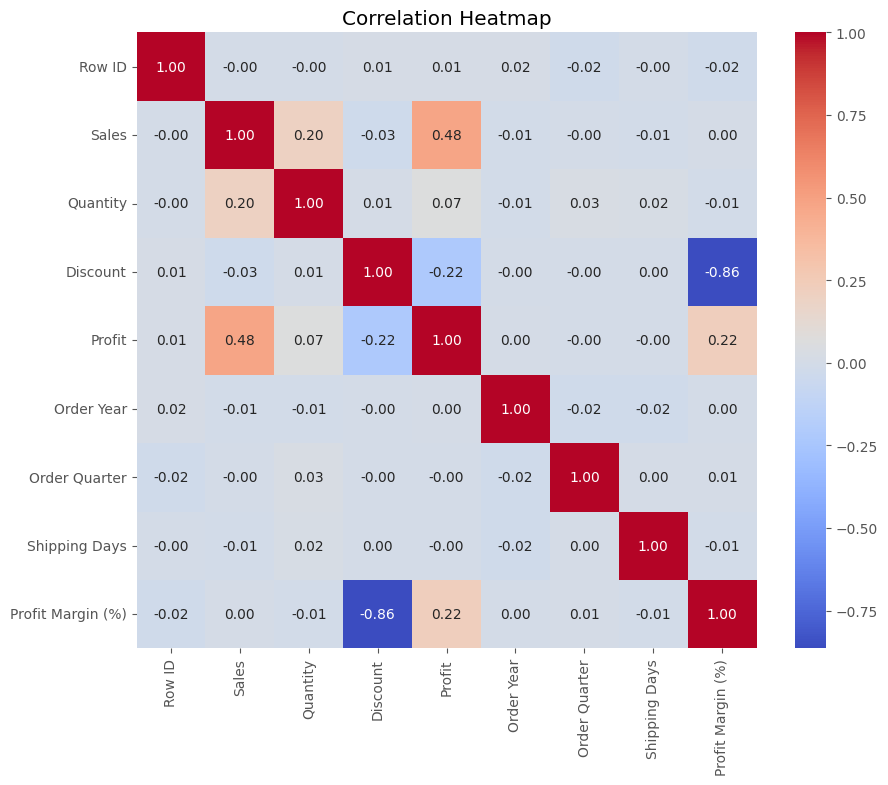

In [42]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

## Business Insight

The correlation heatmap highlights relationships between numerical variables.

Strong positive or negative correlations help identify factors that influence sales and profitability, supporting better business decisions and further analytical modeling.

# Final Business Recommendations

Based on the analysis, the following recommendations are proposed:

1. Increase investment in high-performing product categories such as Technology.

2. Review pricing and discount strategies for low-profit products, especially those with high sales but poor profitability.

3. Focus marketing efforts on the most profitable customer segments.

4. Strengthen sales strategies in underperforming regions.

5. Improve inventory planning using monthly sales trends.

6. Monitor shipping performance to enhance customer satisfaction.

7. Use data-driven decision making for future business growth.